# ARTEMIS boundary analysis during the May 2024 Gannon storm

ARTEMIS is the repurposed THEMIS-B/THEMIS-C pair operating near lunar distance. PySPEDAS therefore still uses the original probe names: **ARTEMIS-2 is THEMIS-C**, or `probe="c"`.

In this notebook we examine a sharp boundary structure observed by ARTEMIS-2 on 10 May 2024. We will move beyond ordinary time-series plotting by using **minimum variance analysis (MVA)** to construct a local coordinate system, rotate both the magnetic field and ion velocity into it, and compare their changes across the boundary.

The event selection and scientific interpretation come from [Nykyri (2024), *Giant Kelvin–Helmholtz (KH) Waves at the Boundary Layer of the Coronal Mass Ejections (CMEs) Responsible for the Largest Geomagnetic Storm in 20 Years*](https://doi.org/10.1029/2024GL110477). Nykyri interprets the broader interval in terms of giant KH-like structures and associated reconnection. Our narrower goal is a single-spacecraft boundary-analysis workflow; these plots alone do not prove a complete reconnection geometry.

## 1. Imports and time intervals

We load 35 minutes for context and use the 15-minute interval reported by Nykyri for MVA. A separate focused range keeps the central plots readable. PySPEDAS downloads daily CDF files, but `time_clip=True` restricts the in-memory variables to this interval.

In [ ]:
# This line installs PySPEDAS so the notebook can be used in Google Colab.  You can comment
# it out or skip this cell if you already have a suitable PySPEDAS installation.

!pip install "pyspedas>=2.2.0"

In [1]:
%matplotlib inline

from datetime import datetime, timezone
from importlib.metadata import version
from pprint import pprint

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pyspedas
from pyspedas import (
    get_data, minvar, options, store_data, time_double, timebar, tplot
)

print("PySPEDAS version:", version("pyspedas"))

overview_trange = ["2024-05-10/22:10", "2024-05-10/22:45"]
mva_trange = ["2024-05-10/22:20", "2024-05-10/22:35"]
focused_trange = ["2024-05-10/22:18", "2024-05-10/22:37"]
transition_time = "2024-05-10/22:30"

PySPEDAS version: 2.2.0


## 2. Load ARTEMIS-2 / THEMIS-C data

We request only the variables used below:

- spin-resolution FGM magnetic field in **GSE** coordinates;
- onboard ESA ion density, ion velocity in **GSE**, and its quality bitmask;
- spacecraft position in **GSE**.

Why MOM rather than the apparently attractive combined ESA+SST `gmom` product? In the currently served 10 May file, the reduced ESA velocity is fill data, the reduced+full GMOM velocity is inconsistent with its stated km/s units, and the physically plausible full-distribution GMOM moments have only about 263 s cadence. The onboard MOM product is finite at about 4.11 s cadence and is the clearest teaching choice for boundary timing. We will inspect its quality flags rather than silently discarding them.

In [2]:
themis = pyspedas.projects.themis

fgm_vars = themis.fgm(
    probe="c", trange=overview_trange,
    varnames=["thc_fgs_gse", "thc_fgs_btotal"],
    time_clip=True,
)
mom_vars = themis.mom(
    probe="c", trange=overview_trange,
    varnames=[
        "thc_peim_data_quality",
        "thc_peim_density",
        "thc_peim_velocity_gse",
    ],
    time_clip=True,
)
state_vars = themis.state(
    probe="c", trange=overview_trange,
    varnames=["thc_pos_gse"],
    time_clip=True,
)

print("FGM returned:", fgm_vars)
print("MOM returned:", mom_vars)
print("State returned:", state_vars)

23-Sep-26 16:51:03: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2024/
23-Sep-26 16:51:04: Downloading https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2024/thc_l2_fgm_20240510_v01.cdf to themis_data/thc/l2/fgm/2024/thc_l2_fgm_20240510_v01.cdf
23-Sep-26 16:51:19: Download of themis_data/thc/l2/fgm/2024/thc_l2_fgm_20240510_v01.cdf complete, 27.079 MB in 15.0 sec (1.806 MB/sec) (transfer_normal)
23-Sep-26 16:51:19: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/mom/2024/
23-Sep-26 16:51:21: Downloading https://themis.ssl.berkeley.edu/data/themis/thc/l2/mom/2024/thc_l2_mom_20240510_v01.cdf to themis_data/thc/l2/mom/2024/thc_l2_mom_20240510_v01.cdf
23-Sep-26 16:51:26: Download of themis_data/thc/l2/mom/2024/thc_l2_mom_20240510_v01.cdf complete, 10.217 MB in 5.9 sec (1.727 MB/sec) (transfer_normal)
23-Sep-26 16:51:27: Downloading https://themis.ssl.berkeley.edu/data/themis/thc/l1/state/2024/thc_l1_state_20240510.cdf to 

FGM returned: ['thc_fgs_gse', 'thc_fgs_btotal']
MOM returned: ['thc_peim_data_quality', 'thc_peim_density', 'thc_peim_velocity_gse']
State returned: ['thc_pos_gse']


### Inspect variable names, metadata, cadence, and quality

Coordinate labels must be checked before applying one rotation matrix to two different vectors. Here both $\mathbf{B}$ and $\mathbf{V}_i$ are explicitly GSE. Density is a scalar, so it has no direction to transform.

In [3]:
b_gse_var = "thc_fgs_gse"
bmag_var = "thc_fgs_btotal"
density_var = "thc_peim_density"
velocity_gse_var = "thc_peim_velocity_gse"
quality_var = "thc_peim_data_quality"
position_var = "thc_pos_gse"

expected = [
    b_gse_var, bmag_var, density_var, velocity_gse_var, quality_var, position_var
]
returned = fgm_vars + mom_vars + state_vars
for name in expected:
    if name not in returned or get_data(name) is None:
        raise RuntimeError(f"Expected variable {name!r} was not loaded")

def summarize(name):
    data = get_data(name)
    metadata = get_data(name, metadata=True)
    cadence = np.nanmedian(np.diff(data.times)) if len(data.times) > 1 else np.nan
    values = np.asarray(data.y)
    print(
        f"{name:25s} shape={str(values.shape):11s} "
        f"cadence={cadence:6.2f} s  "
        f"finite={np.isfinite(values).mean():.3f}  "
        f"coordinates={metadata['data_att'].get('coord_sys')!r}  "
        f"units={metadata['data_att'].get('units')!r}"
    )

for name in expected:
    summarize(name)

b_metadata = get_data(b_gse_var, metadata=True)
v_metadata = get_data(velocity_gse_var, metadata=True)
assert b_metadata["data_att"]["coord_sys"].upper() == "GSE"
assert v_metadata["data_att"]["coord_sys"].upper() == "GSE"

quality_data = get_data(quality_var)
quality_values, quality_counts = np.unique(quality_data.y, return_counts=True)
print("MOM quality flags (value: sample count):")
print(dict(zip(quality_values.tolist(), quality_counts.tolist())))
print("Quality description:")
print(get_data(quality_var, metadata=True)["CDF"]["GATT"]["TEXT"][0])

position_re = np.nanmedian(get_data(position_var).y, axis=0) / 6371.2
print(f"Median ARTEMIS-2 GSE position [R_E]: {position_re.round(2)}")

thc_fgs_gse               shape=(511, 3)    cadence=  4.11 s  finite=1.000  coordinates='GSE'  units='nT GSE'
thc_fgs_btotal            shape=(511,)      cadence=  4.11 s  finite=1.000  coordinates=''  units='nT'
thc_peim_density          shape=(511,)      cadence=  4.11 s  finite=1.000  coordinates=''  units='cm^-3 (All Qs)'
thc_peim_velocity_gse     shape=(511, 3)    cadence=  4.11 s  finite=1.000  coordinates='GSE'  units='km/s (All Qs)'
thc_peim_data_quality     shape=(511,)      cadence=  4.11 s  finite=1.000  coordinates=''  units='0 = Good'
thc_pos_gse               shape=(36, 3)     cadence= 60.00 s  finite=1.000  coordinates='GSE'  units='km'
MOM quality flags (value: sample count):
{0: 180, 16: 320, 32: 11}
Quality description:
THEMIS-C:  On Board moments:  Electron/Ion moments density, flux, velocity, pressure and temperature.Moment Data Quality flags (0: good data; non-zero flags are totals of values; 1: missing S/C potential, 4: ESA Low Energy Electron mode, 8: ESA Low Ene

The MOM quality flag is a bitmask: zero means good; 16 and 32 indicate electron/ion density disagreement. The 32 flag occurs near the sharp transition, so treat individual moment samples and brief velocity spikes cautiously. We retain the delivered samples because removing every nonzero flag would erase much of the event, but our interpretation will emphasize sustained structure and agreement with the published analysis.

## 3. First look in ordinary GSE coordinates

Before calculating MVA, inspect the observations in the mission product's native geocentric solar ecliptic coordinates. Look near 22:30 UT for a rapid change in $B_y$, changes in $B_x$ and $B_z$, structured density, and changing ion flow. Do not label every excursion as reconnection: the paper interprets this combination in the wider context of reconnection associated with a KH-distorted CME boundary.

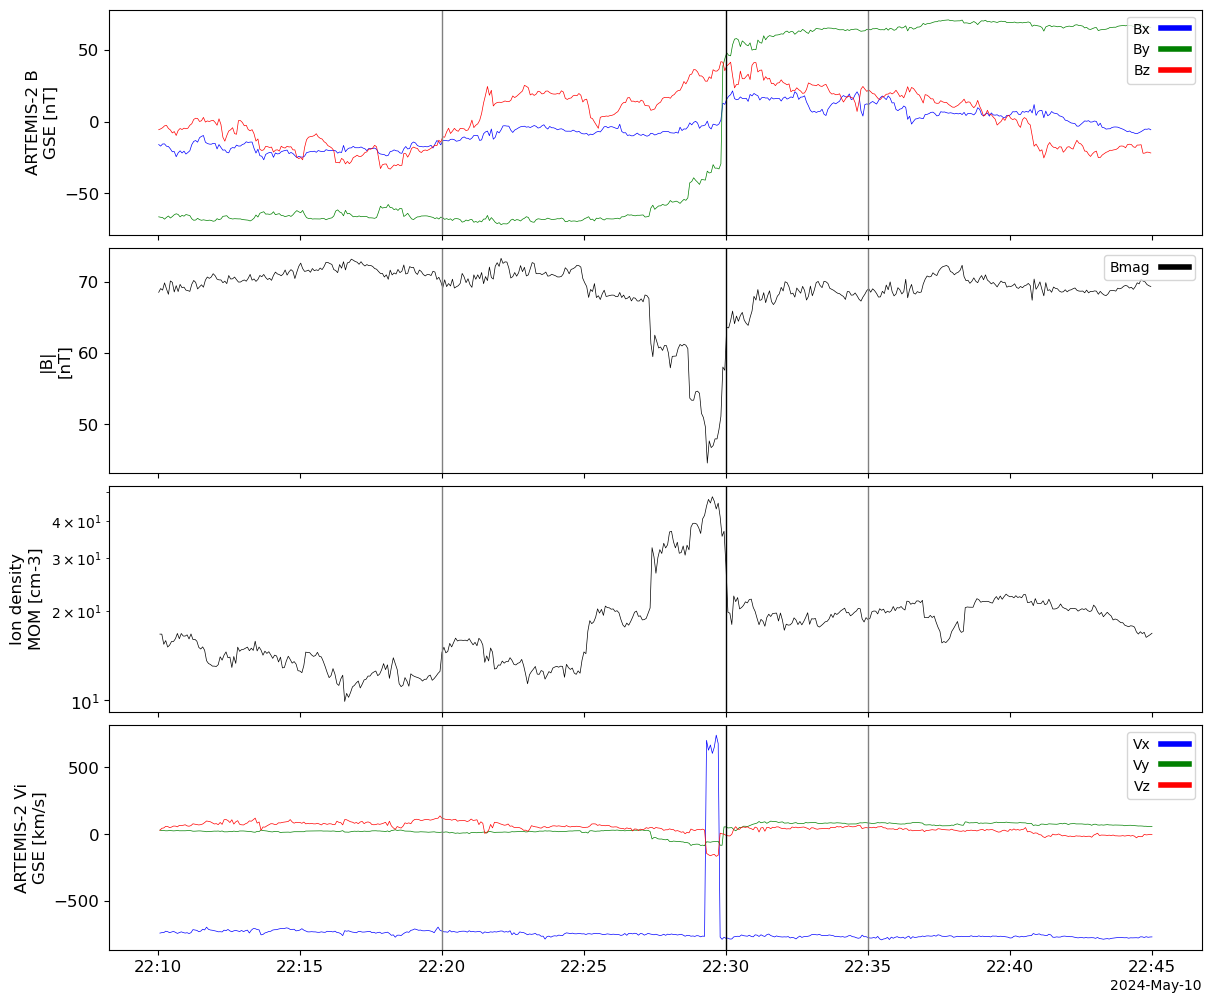

In [4]:
options(b_gse_var, "ytitle", "ARTEMIS-2 B")
options(b_gse_var, "ysubtitle", "GSE [nT]")
options(b_gse_var, "legend_names", ["Bx", "By", "Bz"])
options(bmag_var, "ytitle", "|B|")
options(bmag_var, "ysubtitle", "[nT]")
options(density_var, "ytitle", "Ion density")
options(density_var, "ysubtitle", "MOM [cm^-3]")
options(velocity_gse_var, "ytitle", "ARTEMIS-2 Vi")
options(velocity_gse_var, "ysubtitle", "GSE [km/s]")
options(velocity_gse_var, "legend_names", ["Vx", "Vy", "Vz"])

for guide, color in [
    (mva_trange[0], "gray"),
    (transition_time, "purple"),
    (mva_trange[1], "gray"),
]:
    timebar(time_double(guide), color=color, thick=1)

tplot([b_gse_var, bmag_var, density_var, velocity_gse_var], xsize=12, ysize=10)

## 4. Minimum variance analysis

MVA constructs the covariance matrix of magnetic-field fluctuations and finds its three mutually perpendicular eigenvectors. The directions of maximum, intermediate, and minimum variance provide a local frame. We label them $L$, $M$, and $N$ here:

- $L$: maximum variance; often approximately the reconnecting-field/outflow direction;
- $M$: intermediate variance; often approximately out of the reconnection plane;
- $N$: minimum variance; often approximately the boundary normal.

Those physical identifications are hypotheses, not automatic consequences of the eigenvalue calculation. Large ratios $\lambda_L/\lambda_M$ and $\lambda_M/\lambda_N$ indicate better-separated directions.

In [5]:
b_data = get_data(b_gse_var)
mva_start, mva_stop = time_double(mva_trange)
mva_mask = (b_data.times >= mva_start) & (b_data.times <= mva_stop)
mva_mask &= np.all(np.isfinite(b_data.y), axis=1)
b_for_mva = b_data.y[mva_mask]

print(f"MVA samples: {len(b_for_mva)}")
print(f"Median FGM cadence: {np.median(np.diff(b_data.times[mva_mask])):.3f} s")

# PySPEDAS minvar returns eigenvectors as COLUMNS in descending variance order.
b_mva_native, eigenvectors, eigenvalues = minvar(b_for_mva)

print("Eigenvalues [maximum, intermediate, minimum] in nT^2:")
print(np.array2string(eigenvalues, precision=3))
print(f"lambda_L / lambda_M = {eigenvalues[0] / eigenvalues[1]:.2f}")
print(f"lambda_M / lambda_N = {eigenvalues[1] / eigenvalues[2]:.2f}")
print("Eigenvector matrix V (columns are L, M, N in GSE):")
print(np.array2string(eigenvectors, precision=5, suppress_small=True))

MVA samples: 219
Median FGM cadence: 4.109 s
Eigenvalues [maximum, intermediate, minimum] in nT^2:
[3620.193   97.993   10.713]
lambda_L / lambda_M = 36.94
lambda_M / lambda_N = 9.15
Eigenvector matrix V (columns are L, M, N in GSE):
[[-0.16969  0.13154 -0.97668]
 [-0.98004 -0.12671  0.15321]
 [-0.1036   0.98318  0.15042]]


Nykyri reports approximate eigenvalues $[3244, 297, 11]$ nT$^2$ for 22:20–22:35 UT. With the current Level-2 spin-resolution file and PySPEDAS 2.2.0, the exact minute endpoints give values near $[3620, 98, 10.7]$ nT$^2$. The intermediate value is lower than the published one, but the same strong ordering remains. Differences can arise from source cadence, data version, exact endpoints, and preprocessing; we will not tune the interval merely to force agreement.

### Choose signs and construct a right-handed rotation

An eigenvector and its negative are mathematically equivalent. To make the display reproducible and easy to compare with the paper, we choose $L$ mostly toward $-Y_{GSE}$ and $M$ mostly toward $-Z_{GSE}$. Every sign change is paired with another axis flip so the basis remains right-handed. The sign convention changes component signs, not the physical structure.

In [6]:
# minvar gives columns [L, M, N]. Transpose so the basis vectors are rows.
R_gse_to_lmn = eigenvectors.T.copy()

# Reproducible sign choices motivated by the orientation reported by Nykyri.
if R_gse_to_lmn[0, 1] > 0:   # make L point mostly toward -GSE Y
    R_gse_to_lmn[[0, 2]] *= -1
if R_gse_to_lmn[1, 2] > 0:   # make M point mostly toward -GSE Z
    R_gse_to_lmn[[1, 2]] *= -1

print("R_GSE_to_LMN (rows are L, M, N written in GSE):")
print(np.array2string(R_gse_to_lmn, precision=5, suppress_small=True))
print(f"det(R) = {np.linalg.det(R_gse_to_lmn):.6f}")
print("R @ R.T =")
print(np.array2string(R_gse_to_lmn @ R_gse_to_lmn.T, precision=5))

assert np.allclose(R_gse_to_lmn @ R_gse_to_lmn.T, np.eye(3), atol=1e-12)
assert np.linalg.det(R_gse_to_lmn) > 0

# For one column vector: b_LMN = R @ b_GSE.
# Our samples are stored as rows, so the vectorized equivalent is B @ R.T.
check = b_for_mva @ R_gse_to_lmn.T
print("Rotation convention check passed:", check.shape == b_for_mva.shape)

R_GSE_to_LMN (rows are L, M, N written in GSE):
[[-0.16969 -0.98004 -0.1036 ]
 [-0.13154  0.12671 -0.98318]
 [ 0.97668 -0.15321 -0.15042]]
det(R) = 1.000000
R @ R.T =
[[ 1.00000e+00 -3.29190e-18  9.61672e-19]
 [-3.29190e-18  1.00000e+00  4.19742e-17]
 [ 9.61672e-19  4.19742e-17  1.00000e+00]]
Rotation convention check passed: True


## 5. Rotate the magnetic field and ion velocity

The MVA basis is constant for this 15-minute analysis. Therefore the magnetic field and velocity may retain their own timestamps; no interpolation between the products is required. What *is* required is that both input vectors use the same original coordinate system—GSE here.

In [7]:
velocity_data = get_data(velocity_gse_var)
density_data = get_data(density_var)

b_lmn = b_data.y @ R_gse_to_lmn.T
v_lmn = velocity_data.y @ R_gse_to_lmn.T
b_magnitude = np.linalg.norm(b_data.y, axis=1)

# Keep the original MOM vectors, but omit flag-32 samples from the central display.
# These 11 samples create an implausible reversal of the dominant solar-wind flow.
v_lmn_display = v_lmn.copy()
v_lmn_display[quality_data.y == 32] = np.nan

store_data("thc_fgs_lmn", data={"x": b_data.times, "y": b_lmn})
store_data("thc_peim_velocity_lmn", data={"x": velocity_data.times, "y": v_lmn})
options("thc_fgs_lmn", "legend_names", ["B_L", "B_M", "B_N"])
options("thc_fgs_lmn", "ysubtitle", "MVA [nT]")
options("thc_peim_velocity_lmn", "legend_names", ["V_L", "V_M", "V_N"])
options("thc_peim_velocity_lmn", "ysubtitle", "MVA [km/s]")

print("Created tplot variables: thc_fgs_lmn, thc_peim_velocity_lmn")

Created tplot variables: thc_fgs_lmn, thc_peim_velocity_lmn


## 6. Combined boundary-analysis figure

This is the central scientific figure. The gray band is the MVA interval and the purple guide marks 22:30 UT. Compare the dominant reversal in $B_L$ with density structure and the changes in $V_L$. The large, nearly steady $V_N$ mostly reflects the fast Earthward solar-wind/CME flow projected onto a normal that lies mainly along $+X_{GSE}$; it should not be mistaken for the smaller jet-like change in $V_L$. The 11 MOM samples with quality flag 32 are omitted from the velocity traces, leaving a short visible gap rather than a misleading reversal. The raw values remain in the original tplot variable and in the overview above.

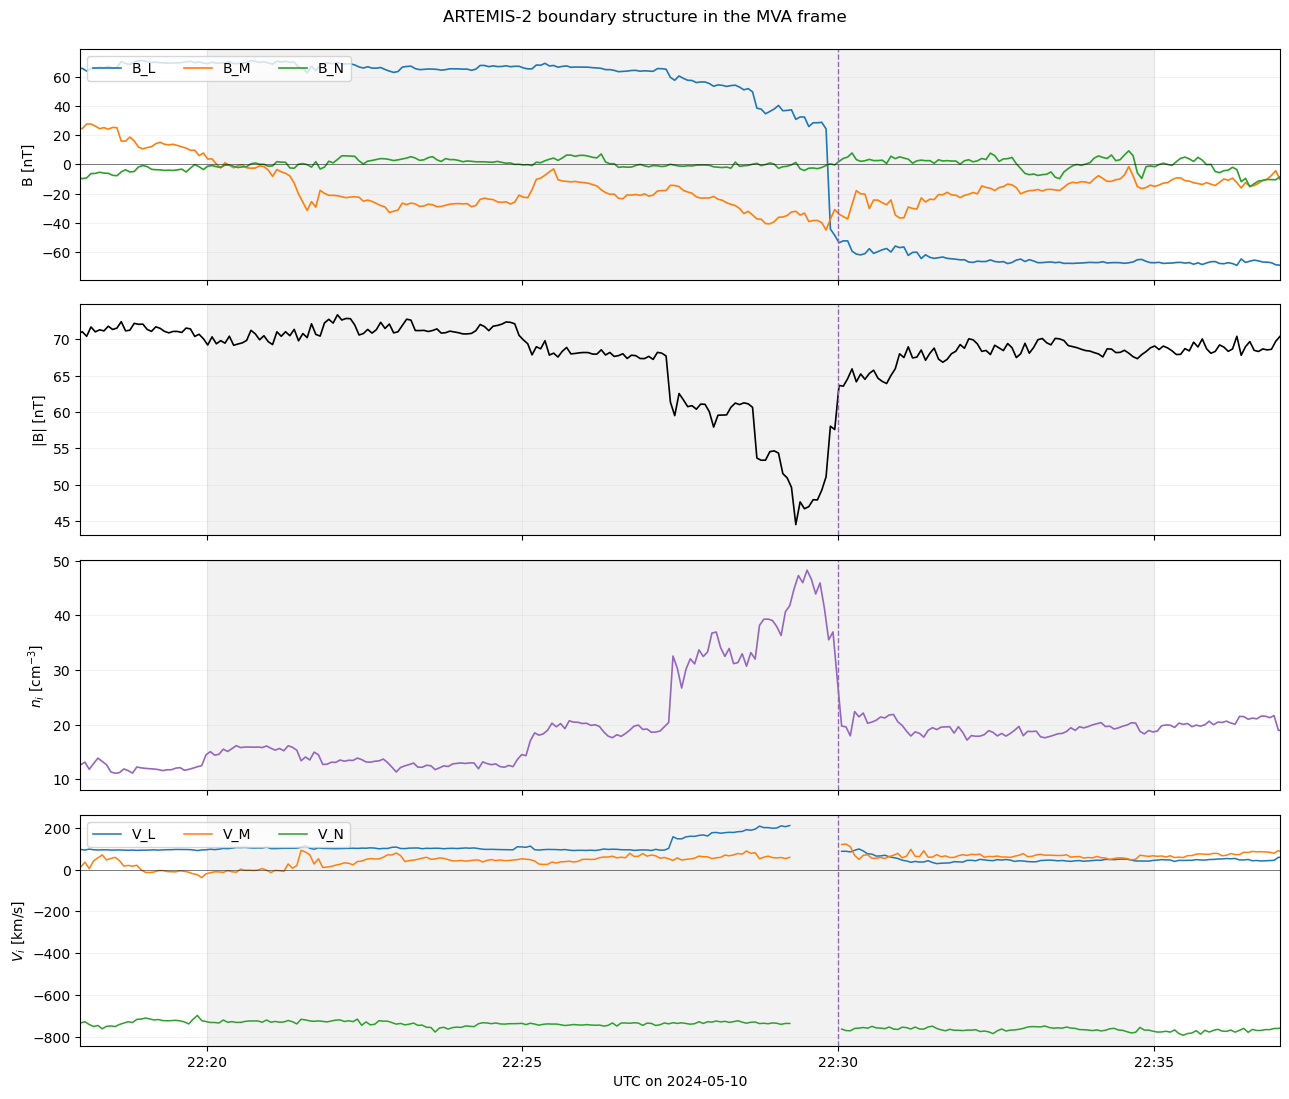

In [8]:
def utc_datetimes(times):
    return [datetime.fromtimestamp(float(t), tz=timezone.utc) for t in times]

b_times = utc_datetimes(b_data.times)
v_times = utc_datetimes(velocity_data.times)
n_times = utc_datetimes(density_data.times)
plot_start = datetime.fromtimestamp(time_double(focused_trange[0]), tz=timezone.utc)
plot_stop = datetime.fromtimestamp(time_double(focused_trange[1]), tz=timezone.utc)
shade_start = datetime.fromtimestamp(mva_start, tz=timezone.utc)
shade_stop = datetime.fromtimestamp(mva_stop, tz=timezone.utc)
transition_dt = datetime.fromtimestamp(time_double(transition_time), tz=timezone.utc)

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
colors = ["blue", "orange", "green"]

for index, (label, color) in enumerate(zip(["B_L", "B_M", "B_N"], colors)):
    axes[0].plot(b_times, b_lmn[:, index], color=color, lw=1.2, label=label)
axes[0].axhline(0, color="black", lw=0.7, alpha=0.5)
axes[0].set_ylabel("B [nT]")
axes[0].legend(loc="upper left", ncol=3)

axes[1].plot(b_times, b_magnitude, color="black", lw=1.2)
axes[1].set_ylabel("|B| [nT]")

axes[2].plot(n_times, density_data.y, color="purple", lw=1.2)
axes[2].set_ylabel(r"$n_i$ [cm$^{-3}$]")

for index, (label, color) in enumerate(zip(["V_L", "V_M", "V_N"], colors)):
    axes[3].plot(v_times, v_lmn_display[:, index], color=color, lw=1.1, label=label)
axes[3].axhline(0, color="black", lw=0.7, alpha=0.5)
axes[3].set_ylabel(r"$V_i$ [km/s]")
axes[3].legend(loc="upper left", ncol=3)

for ax in axes:
    ax.axvspan(shade_start, shade_stop, color="0.8", alpha=0.25)
    ax.axvline(transition_dt, color="purple", ls="--", lw=1)
    ax.grid(alpha=0.2)
    ax.set_xlim(plot_start, plot_stop)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=timezone.utc))
axes[-1].set_xlabel("UTC on 2024-05-10")
fig.suptitle("ARTEMIS-2 boundary structure in the MVA frame", y=0.995)
fig.tight_layout()

In [9]:
velocity_mva_mask = (velocity_data.times >= mva_start) & (velocity_data.times <= mva_stop)
velocity_mva_mask &= quality_data.y != 32
v_l_interval = v_lmn[velocity_mva_mask, 0]
t_interval = velocity_data.times[velocity_mva_mask]
i_min = np.nanargmin(v_l_interval)
i_max = np.nanargmax(v_l_interval)

print("V_L range during the MVA interval (quality flag 32 omitted):")
print(
    f"  minimum {v_l_interval[i_min]:.1f} km/s at "
    f"{datetime.fromtimestamp(t_interval[i_min], tz=timezone.utc):%H:%M:%S} UT"
)
print(
    f"  maximum {v_l_interval[i_max]:.1f} km/s at "
    f"{datetime.fromtimestamp(t_interval[i_max], tz=timezone.utc):%H:%M:%S} UT"
)
print("Published fixed-frame V_L jet magnitude: approximately 300 km/s.")
print("A reversed L axis would reverse both printed signs without changing the result.")

V_L range during the MVA interval (quality flag 32 omitted):
  minimum 28.2 km/s at 22:31:33 UT
  maximum 210.9 km/s at 22:29:14 UT
Published fixed-frame V_L jet magnitude: approximately 300 km/s.
A reversed L axis would reverse both printed signs without changing the result.


The transformed field isolates a large $B_L$ reversal while $B_N$ remains much smaller, which is the pattern expected when MVA captures a boundary-aligned frame. After omitting the flag-32 samples, the MOM velocity shows a sustained change of order a few hundred km/s in $V_L$, broadly comparable with the approximately 300 km/s fixed-frame value discussed by Nykyri. Exact amplitude and sign depend on the moment product, interval, and eigenvector signs. The density-quality flags and brief velocity excursions are reasons to interpret timing and sustained changes rather than a single extreme sample.

## 7. Exercises

### Exercise A: change the MVA interval

Move either endpoint by one or two minutes and repeat the calculation. Which eigenvector changes most? Do $\lambda_L/\lambda_M$ and $\lambda_M/\lambda_N$ improve or worsen? Interval sensitivity is part of the analysis, not an inconvenience to hide.

### Exercise B: eigenvector sign ambiguity

Compare your basis with the displayed one or with the published orientation. Are any axes different only by a factor of $-1$? Flip one axis and observe that the determinant becomes negative; then flip a second axis to restore a right-handed system.

### Exercise C: identify the plasma jet

Estimate the sustained peak $|V_L|$ and its time without using a single flagged spike. How close is it to the magnetic rotation? Compare its magnitude—not necessarily its sign—with the value reported in the paper.

### Exercise D: native versus MVA coordinates

Place the first GSE plot beside the combined MVA figure. Why does concentrating the rotation into $B_L$ make the boundary easier to interpret? What information is still ambiguous in a single-spacecraft crossing?

In [10]:
# Starter for Exercise A: uncomment, change the endpoints, and compare.
# trial_trange = ["2024-05-10/22:21", "2024-05-10/22:34"]
# trial_start, trial_stop = time_double(trial_trange)
# trial_mask = (b_data.times >= trial_start) & (b_data.times <= trial_stop)
# _, trial_vectors, trial_values = minvar(b_data.y[trial_mask])
# print(trial_values)
# print(trial_vectors)

## 8. Scientific takeaway

ARTEMIS-2 observed a strong magnetic rotation, structured density, and changing plasma flow during the 10 May 2024 storm. MVA supplies a local, right-handed coordinate system in which the dominant magnetic reversal and associated flow change are easier to see than in GSE. The separated eigenvalues support the usefulness of that frame, while the interval sensitivity, sign ambiguity, plasma quality flags, and single-spacecraft geometry limit how strongly we should identify $L$, $M$, and $N$ with an ideal reconnection geometry.

Nykyri (2024) interprets this structure within a broader sequence of giant Kelvin–Helmholtz-like CME-boundary waves and reconnection-related jets. Our observations are consistent with that published interpretation, but this notebook is an analysis exercise rather than an independent proof of the full scenario.

## Instructor notes and current caveats

- THEMIS loaders download daily CDF files. On a fresh machine, FGM, MOM, and state together are tens of MB; reruns use the local cache.
- ARTEMIS-2 remains `probe="c"`, and variable names begin `thc_`. `thc_fgs_gse` is spin-resolution FGM; `thc_peim_*` is onboard ESA ion MOM.
- Both vectors rotated here are GSE. The constant MVA matrix must not be applied to a DSL, GSM, or other vector without first transforming that vector into GSE.
- In PySPEDAS 2.2.0, `minvar` returns eigenvectors as **columns** ordered maximum/intermediate/minimum. For row-wise samples, `B @ eigenvectors` matches the returned rotated data. This notebook transposes the basis into `R`, whose rows are $L,M,N$, so the single-vector convention is `b_LMN = R @ b_GSE` and the vectorized convention is `B_LMN = B_GSE @ R.T`.
- The exact minute endpoints currently yield eigenvalues near `[3620, 98, 10.7]` nT$^2$, compared with the published approximate `[3244, 297, 11]`. The ordering and minimum-variance separation are robust, but the intermediate eigenvalue is product/preprocessing sensitive.
- Eigenvector signs are arbitrary. The explicit paired flips orient $L$ mostly along $-Y_{GSE}$ and $M$ mostly along $-Z_{GSE}$ while keeping `det(R) = +1`.
- The reduced ESA velocity (`thc_peir_velocity_gse`) is fill data in this interval. The current reduced+full GMOM velocity (`thc_ptirf_velocity_gse`) is inconsistent with its stated km/s units and has nonzero quality flags. Full-distribution GMOM (`thc_ptiff_*`) is physically plausible but only about 263 s cadence. MOM therefore provides the clearest classroom time series, with its quality flags shown.
- MOM flags 16 and 32 describe electron/ion density disagreement. Flag 32 overlaps the sharp transition; do not base the jet amplitude on one extreme sample. A final research reproduction should compare calibrated particle products and the exact processing used by the paper.
- Ion pitch-angle distributions are scientifically interesting here, but producing and validating them would distract from the MVA workflow. They are a good later supplement.
- The 11 May 08:25:41–08:45:41 UT interval is a natural future supplement on the deHoffmann–Teller frame and Walén relation. PySPEDAS supplies the data and vector utilities, but the regression, quality criteria, pressure-anisotropy choice, and uncertainty treatment should be developed explicitly rather than added as a short appendix.